In [14]:
!pip install infomap


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.8/264.8 kB 6.7 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for infomap: filename=infomap-2.8.0-cp311-cp311-macosx_11_0_arm64.whl size=560363 sha256=d42c82b4b5baa78f042dbefb18a2a255a4a7477393482685ea5729bdf4312c1d
  Stored in directory: /Users/mariaboubekeur/Library/Caches/pip/wheels/f2/07/de/ee649642ec15485c0eaf89c9f06eb4f19a9b45e744e6808a8d
Successfully built infomap


Taille après nettoyage : (341, 3)

Graph non pondéré : 81 nœuds / 341 arêtes
Graph pondéré : 81 nœuds / 341 arêtes
dans l'article ils ont travaillé avec un graphique de 86 nodes and 355 edges 


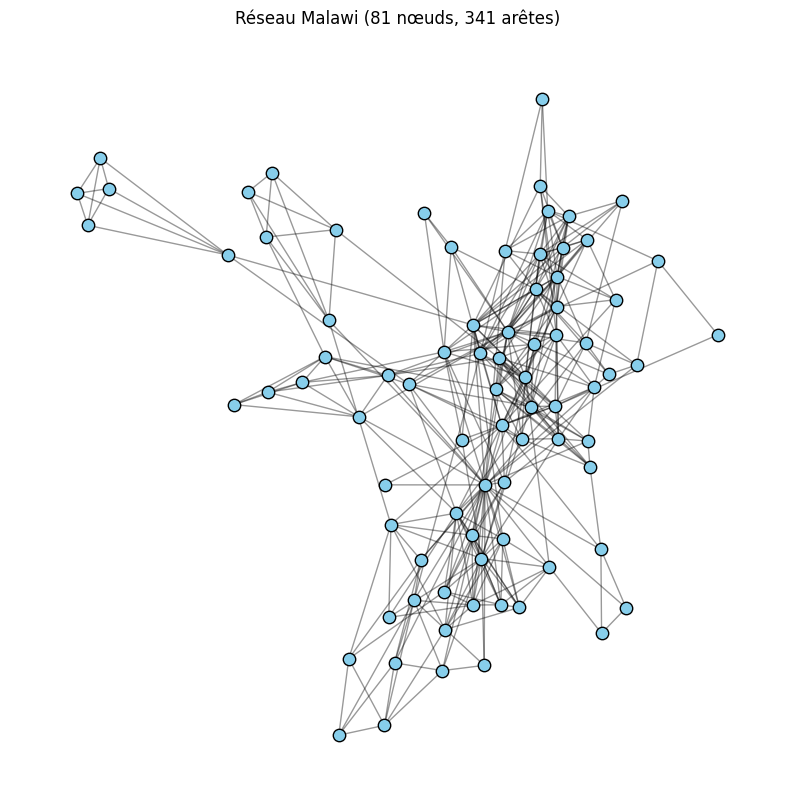


Louvain (non pondéré) : 7 communautés | modularité = 0.5028465527472245
Louvain (pondéré) : 21 communautés | modularité = 0.8915791804567895

Stabilité Louvain — Non pondéré : [7, 7, 6, 7, 7, 7, 6, 7, 7, 7, 7, 7, 7, 6, 6, 7, 7, 7, 7, 7]
Stabilité Louvain — Pondéré : [21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21]


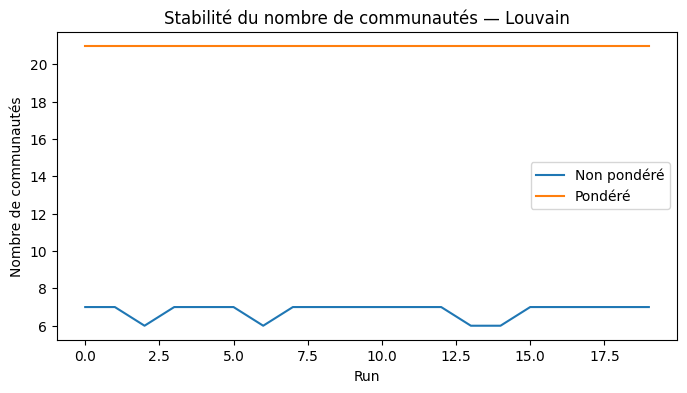


Walktrap : 8 communautés
Tailles : [18, 3, 24, 12, 6, 5, 8, 5]

Infomap : 7 communautés
  Infomap v2.8.0 starts at 2025-12-15 22:00:29
  -> Input network: 
  -> No file output!
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 81 nodes and 341 links...
  -> One-level codelength: 6.11583561

Trial 1/1 starting at 2025-12-15 22:00:29
Two-level compression: 11% 2.6% 
Partitioned to codelength 0.462120092 + 4.82542937 = 5.287549458 in 7 modules.
Super-level compression: to codelength 5.287549458 in 7 top modules.

Recursive sub-structure compression: 0% . Found 2 levels with codelength 5.287549458

=> Trial 1/1 finished in 0.0008275s with codelength 5.28754946


Summary after 1 trial
Best end modular solution in 2 levels:
Per level number of modules:         [          7,           0] (sum: 7)
Per

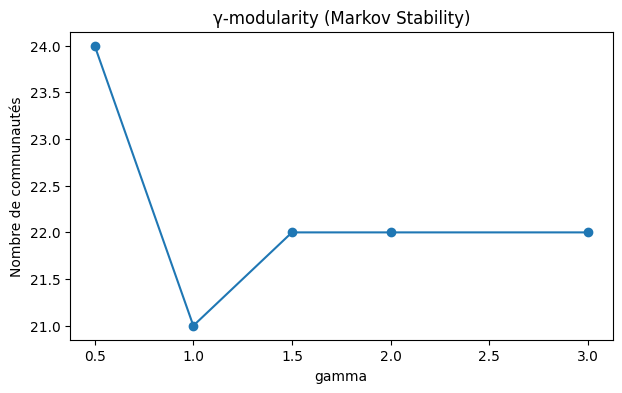


K-core maximal = 7
Taille du core : 31
Taille de la périphérie : 0

   CHAPITRE 9 : EPIDEMIES 

Plus grande valeur propre λ_max = 11.934231861345472
Seuil épidémique (β/μ > 1/λ_max) = 0.08379257346582669

Top superspreaders (stationary distribution) :
    node  degree  eigenvector  stationary
37    16      31     0.257431    0.045455
28    81      26     0.310695    0.038123
14    69      18     0.144391    0.026393
17    74      17     0.233809    0.024927
0      1      16     0.182185    0.023460
16    70      16     0.223776    0.023460
77    63      15     0.213839    0.021994
20    52      15     0.204513    0.021994
9     86      15     0.137257    0.021994
36    54      14     0.207212    0.020528


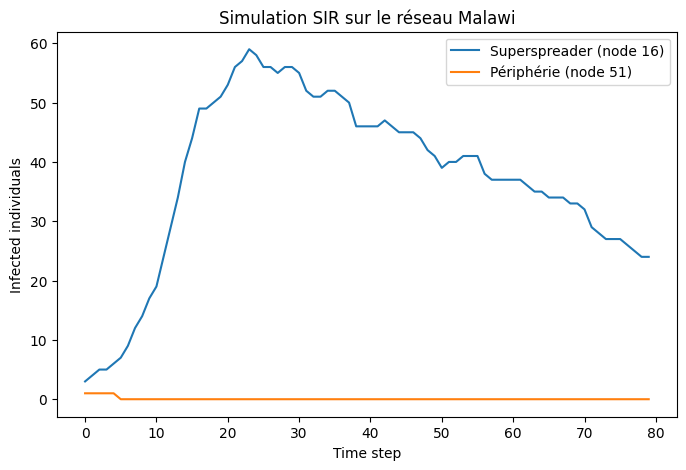


------ COMPARAISON AVEC ARTICLE (Section 3.2) ------
ARTICLE = 8 communautés (non pondéré), 13 (pondéré)
TOI     = 7 (non pondéré), 21 (pondéré)

ARTICLE = modularité 0.48 (non pondéré), 0.75 (pondéré)
TOI     = modularité 0.503 (non pondéré), 0.892 (pondéré)


In [4]:
# ============================================================
# ANALYSE COMPLETE DU RESEAU MALAWI
# Louvain – Stabilité – Walktrap – Infomap – Spectral – γ-modularity – k-core
# ============================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from community import community_louvain
from sklearn.cluster import SpectralClustering
import igraph as ig
from infomap import Infomap


# ------------------------------------------------------------
# 1. CHARGEMENT & NETTOYAGE DU DATASET
# ------------------------------------------------------------

df = pd.read_csv("../dataset/tnet_malawi_pilot.csv")
df = df.drop(columns=["Unnamed: 0"], errors='ignore')

# Retirer contacts de durée 0
df = df[df["contact_time"] > 0]

# Agréger la durée totale des contacts id1-id2
df_agg = df.groupby(["id1", "id2"])["contact_time"].sum().reset_index()
df_agg.rename(columns={"contact_time": "weight"}, inplace=True)

# Retirer individus peu actifs (<3 contacts)
deg = pd.concat([df_agg["id1"], df_agg["id2"]]).value_counts()
valid_ids = deg[deg >= 3].index

df_clean = df_agg[df_agg["id1"].isin(valid_ids) & df_agg["id2"].isin(valid_ids)]
print("Taille après nettoyage :", df_clean.shape)


# ------------------------------------------------------------
# 2. CONSTRUCTION DES GRAPHES PONDÉRÉ ET NON-PONDÉRÉ
# ------------------------------------------------------------

G = nx.from_pandas_edgelist(df_clean, "id1", "id2")                     # non pondéré
Gw = nx.from_pandas_edgelist(df_clean, "id1", "id2", edge_attr="weight") # pondéré

print("\nGraph non pondéré :", G.number_of_nodes(), "nœuds /", G.number_of_edges(), "arêtes")
print("Graph pondéré :", Gw.number_of_nodes(), "nœuds /", Gw.number_of_edges(), "arêtes")
print("dans l'article ils ont travaillé avec un graphique de 86 nodes and 355 edges ")

plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G, seed=42)  # positions des nœuds

nx.draw_networkx_nodes(G, pos, node_size=80, node_color="skyblue", edgecolors="black")
nx.draw_networkx_edges(G, pos, alpha=0.4)

plt.title("Réseau Malawi (81 nœuds, 341 arêtes)")
plt.axis('off')
plt.show()



# ------------------------------------------------------------
# 3. LOUVAIN PONDÉRÉ / NON PONDÉRÉ
# ------------------------------------------------------------

part_unw = community_louvain.best_partition(G)
part_w = community_louvain.best_partition(Gw, weight="weight")

mod_unw = community_louvain.modularity(part_unw, G)
mod_w = community_louvain.modularity(part_w, Gw)

print("\nLouvain (non pondéré) :", len(set(part_unw.values())), "communautés | modularité =", mod_unw)
print("Louvain (pondéré) :", len(set(part_w.values())), "communautés | modularité =", mod_w)


# ------------------------------------------------------------
# 4. STABILITÉ DU LOUVAIN SUR 20 RUNS
# ------------------------------------------------------------

def louvain_runs(G, weighted=False, n=20):
    results = []
    for _ in range(n):
        if weighted:
            p = community_louvain.best_partition(G, weight="weight")
        else:
            p = community_louvain.best_partition(G)
        results.append(len(set(p.values())))
    return results

runs_unw = louvain_runs(G, weighted=False)
runs_w = louvain_runs(Gw, weighted=True)

print("\nStabilité Louvain — Non pondéré :", runs_unw)
print("Stabilité Louvain — Pondéré :", runs_w)

plt.figure(figsize=(8,4))
plt.plot(runs_unw, label="Non pondéré")
plt.plot(runs_w, label="Pondéré")
plt.title("Stabilité du nombre de communautés — Louvain")
plt.xlabel("Run")
plt.ylabel("Nombre de communautés")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 5. WALKTRAP (iGraph)
# ------------------------------------------------------------

g_ig = ig.Graph.TupleList(G.edges(), directed=False)
walk = g_ig.community_walktrap().as_clustering()

walk_coms = walk.sizes()
walk_k = len(walk_coms)

print("\nWalktrap :", walk_k, "communautés")
print("Tailles :", walk_coms)


# ------------------------------------------------------------
# 6. INFOMAP
# ------------------------------------------------------------

im = Infomap()
for u, v in G.edges():
    im.add_link(u, v)

im.run()

infomap_assign = {node.node_id: node.module_id for node in im.iterTree() if node.isLeaf()}
infomap_k = len(set(infomap_assign.values()))

print("\nInfomap :", infomap_k, "communautés")


# ------------------------------------------------------------
# 7. SPECTRAL CLUSTERING
# ------------------------------------------------------------

A = nx.to_numpy_array(G)
k_spec = len(set(part_unw.values()))

spec = SpectralClustering(n_clusters=k_spec, affinity='precomputed', assign_labels='kmeans')
labels = spec.fit_predict(A)
spec_sizes = pd.Series(labels).value_counts().tolist()

print("\nSpectral Clustering :", k_spec, "communautés")
print("Tailles :", spec_sizes)


# ------------------------------------------------------------
# 8. γ-MODULARITÉ
# ------------------------------------------------------------

gammas = [0.5, 1.0, 1.5, 2.0, 3.0]
gamma_res = []

for gamma in gammas:
    part = community_louvain.best_partition(Gw, resolution=gamma, weight="weight")
    Q = community_louvain.modularity(part, Gw)
    k = len(set(part.values()))
    gamma_res.append((gamma, Q, k))
    print(f"γ={gamma} → modularité={Q:.4f}, communautés={k}")

plt.figure(figsize=(7,4))
plt.plot(gammas, [k for (_,_,k) in gamma_res], marker='o')
plt.xlabel("gamma")
plt.ylabel("Nombre de communautés")
plt.title("γ-modularity (Markov Stability)")
plt.show()


# ------------------------------------------------------------
# 9. K-CORE DECOMPOSITION
# ------------------------------------------------------------

core = nx.core_number(G)
maxcore = max(core.values())

core_nodes = [n for n, c in core.items() if c == maxcore]
periphery_nodes = [n for n, c in core.items() if c == 1]

print("\nK-core maximal =", maxcore)
print("Taille du core :", len(core_nodes))
print("Taille de la périphérie :", len(periphery_nodes))

# =============================================================
# 11. CHAPITRE 9 — ÉPIDÉMIES SUR RÉSEAUX
# =============================================================

print("\n==========================")
print("   CHAPITRE 9 : EPIDEMIES ")
print("==========================")

# -------------------------------------------------------------
# 11.1 Calcul du plus grand eigenvalue λ_max
# -------------------------------------------------------------

A = nx.to_numpy_array(G)  # graphe non pondéré pour correspondre à l’article
eigs = np.linalg.eigvals(A)
lambda_max = max(eigs.real)

print("\nPlus grande valeur propre λ_max =", lambda_max)
print("Seuil épidémique (β/μ > 1/λ_max) =", 1/lambda_max)

# -------------------------------------------------------------
# 11.2 Identification des superspreaders
# -------------------------------------------------------------

deg_cent = dict(G.degree())
eig_cent = nx.eigenvector_centrality_numpy(G)
rw_stat = {n: deg_cent[n] / sum(deg_cent.values()) for n in G.nodes()}

df_sup = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [deg_cent[n] for n in G.nodes()],
    "eigenvector": [eig_cent[n] for n in G.nodes()],
    "stationary": [rw_stat[n] for n in G.nodes()]
}).sort_values(by="stationary", ascending=False)

print("\nTop superspreaders (stationary distribution) :")
print(df_sup.head(10))

super_node = int(df_sup.iloc[0]["node"])   # patient zéro = superspreader
periph_node = int(df_sup.iloc[-1]["node"]) # patient zéro = périphérie


# -------------------------------------------------------------
# 11.3 Simulation SIR
# -------------------------------------------------------------

def run_SIR(G, patient_zero, beta=0.03, mu=0.02, steps=80):
    status = {n: "S" for n in G.nodes()}
    status[patient_zero] = "I"
    infected_counts = []

    for _ in range(steps):
        new_status = status.copy()
        for n in G.nodes():
            if status[n] == "I":
                # Recovery
                if np.random.rand() < mu:
                    new_status[n] = "R"
                # Infection
                for neigh in G.neighbors(n):
                    if status[neigh] == "S" and np.random.rand() < beta:
                        new_status[neigh] = "I"
        status = new_status
        infected_counts.append(list(status.values()).count("I"))
    return infected_counts


I_super = run_SIR(G, super_node)
I_periph = run_SIR(G, periph_node)

plt.figure(figsize=(8,5))
plt.plot(I_super, label=f"Superspreader (node {super_node})")
plt.plot(I_periph, label=f"Périphérie (node {periph_node})")
plt.xlabel("Time step")
plt.ylabel("Infected individuals")
plt.title("Simulation SIR sur le réseau Malawi")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 10. COMPARAISON AVEC L’ARTICLE
# ------------------------------------------------------------

print("\n------ COMPARAISON AVEC ARTICLE (Section 3.2) ------")
print("ARTICLE = 8 communautés (non pondéré), 13 (pondéré)")
print("TOI     =", len(set(part_unw.values())), "(non pondéré),", len(set(part_w.values())), "(pondéré)")

print("\nARTICLE = modularité 0.48 (non pondéré), 0.75 (pondéré)")
print("TOI     = modularité", round(mod_unw,3), "(non pondéré),", round(mod_w,3), "(pondéré)")



10 plus petites valeurs propres du Laplacien normalisé :
[0.000000, 0.067468, 0.133371, 0.148500, 0.233218, 0.304430, 0.326033, 0.388837, 0.470559, 0.527129]


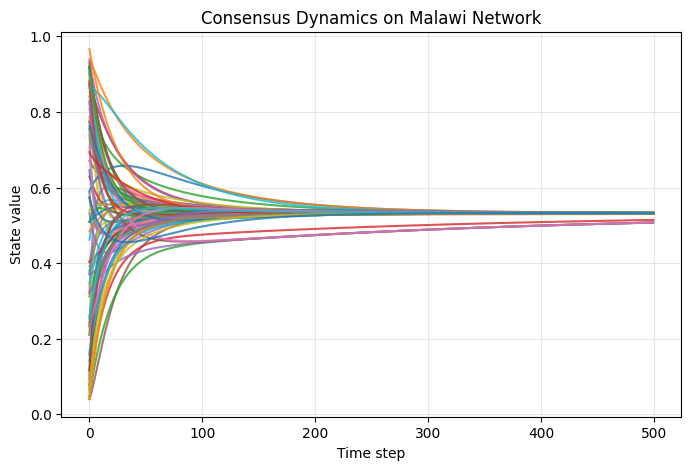

In [ ]:
# ============================================================
# 12. SPECTRE DU LAPLACIEN & CONSENSUS (Chapitre 6)
# ============================================================

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 12.1 ORDONNER LES NOEUDS (CRUCIAL !!)
# ------------------------------------------------------------

nodes = list(G.nodes())     # ordre fixe
n = len(nodes)

# ------------------------------------------------------------
# 12.2 VALEURS PROPRES DU LAPLACIEN NORMALISÉ
# ------------------------------------------------------------
L_norm = nx.normalized_laplacian_matrix(G, nodelist=nodes).astype(float).todense()
eigenvalues = np.linalg.eigvals(L_norm)
eigenvalues = np.sort(np.real(eigenvalues))

print("\n10 plus petites valeurs propres du Laplacien normalisé :")

# formatage avec séparateur virgule + 4 décimales
formatted = ", ".join([f"{val:.6f}" for val in eigenvalues[:10]])
print(f"[{formatted}]")

# ------------------------------------------------------------
# 12.3 LAPLCIEN NON NORMALISÉ POUR CONSENSUS
# ------------------------------------------------------------

L = nx.laplacian_matrix(G, nodelist=nodes).astype(float).todense()
L = np.array(L)

# ------------------------------------------------------------
# 12.4 SIMULATION DE CONSENSUS :  x_dot = -L x
# ------------------------------------------------------------

x = np.random.rand(n)   # état initial aléatoire
dt = 0.01
steps = 500

X = np.zeros((steps, n))

for t in range(steps):
    x = x - dt * (L @ x)
    X[t] = x

# ------------------------------------------------------------
# 12.5 PLOT DU CONSENSUS
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
plt.plot(X, alpha=0.8)
plt.title("Consensus Dynamics on Malawi Network")
plt.xlabel("Time step")
plt.ylabel("State value")
plt.grid(alpha=0.3)
plt.show()
